Task 6 — Netflix Business Insights Report

In [1]:
#Step 1: Complete Exploratory Data Analysis

#Load the dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_cleaned.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [2]:
#Check dataset dimensions
df.shape

(8790, 10)

In [3]:
#Check column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [4]:
#Check missing values
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [5]:
#check duplicate records
df.duplicated().sum()

np.int64(0)

In [6]:
#statiscal summary
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
#Check unique values
df["type"].unique()              #content type

array(['Movie', 'TV Show'], dtype=object)

In [8]:
df["rating"].unique()            #ratings

array(['PG-13', 'TV-MA', 'TV-PG', 'TV-14', 'TV-Y7', 'TV-Y', 'PG', 'TV-G',
       'R', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [9]:
df["release_year"].nunique()           #release years

74

In [10]:
df["title"].nunique()             #no. of unique titles

8787

In [11]:
#Create a quick EDA summary
eda_summary = {"Total Records": len(df),"Total Columns": df.shape[1],
    "Unique Titles": df["title"].nunique(),
    "Unique Release Years": df["release_year"].nunique(),
    "Movies": (df["type"] == "Movie").sum(),
    "TV Shows": (df["type"] == "TV Show").sum()}
eda_summary

{'Total Records': 8790,
 'Total Columns': 10,
 'Unique Titles': 8787,
 'Unique Release Years': 74,
 'Movies': np.int64(6126),
 'TV Shows': np.int64(2664)}

## Step 1: Exploratory Data Analysis

The Netflix dataset was explored to understand its overall structure, quality, and key characteristics before performing deeper business analysis.

### EDA Performed:
- Examined the dataset size and structure
- Checked column names and data types
- Analyzed missing values
- Checked for duplicate records
- Reviewed statistical information
- Identified unique titles and release years
- Analyzed the distribution of Movies and TV Shows

### Key Findings:
- Total Records: **8,790**
- Total Columns: **10**
- Unique Titles: **8,787**
- Unique Release Years: **74**
- Movies: **6,126**
- TV Shows: **2,664**

This exploratory analysis provides a foundation for identifying important content trends, audience patterns, and business insights in the following stages.

In [12]:
#Step 2: Identify Key Content Trends & Patterns

#Movies vs TV Shows
content_type = df["type"].value_counts()
content_type

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [13]:
#calculate percentage
content_type_percentage = (df["type"].value_counts(normalize=True) * 100
).round(2)
content_type_percentage

type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64

In [14]:
#Release-year trend
yearly_content = (df["release_year"].value_counts().sort_index())
yearly_content

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

In [15]:
#top 10 release years
top_release_years = (yearly_content.sort_values(ascending=False).head(10))
top_release_years

release_year
2018    1146
2019    1030
2017    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: count, dtype: int64

In [16]:
#Rating distribution
rating_counts = df["rating"].value_counts()
rating_counts

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [18]:
# Top 10 ratings
top_ratings = rating_counts.head(10)
top_ratings

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

In [19]:
#Genre analysis
genre_data = (df["listed_in"].dropna().str.split(",").explode().str.strip())

genre_counts = genre_data.value_counts()
genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

## Step 2: Identify Key Content Trends and Patterns

The Netflix dataset was analyzed to identify important content trends and patterns across content types, release years, ratings, and genres.

### Analysis Performed:
- Compared the distribution of Movies and TV Shows
- Analyzed content trends across release years
- Identified the most common content ratings
- Analyzed the most frequently occurring genres and categories
- Compared content patterns to understand Netflix's audience focus

### Key Findings:
- **TV-MA** is the most common content rating with **3,205 titles**.
- **TV-14** is the second most common rating with **2,157 titles**.
- **International Movies** is the most frequently occurring genre/category with **2,752 titles**.
- **Dramas** are the second most common category with **2,426 titles**.
- **Comedies** rank among the most frequently occurring categories with **1,674 titles**.

The analysis highlights Netflix's strong focus on mature and teen-oriented content, along with a diverse catalog containing significant international, drama, and comedy content.

In [23]:
#Step 3: Develop Multiple Visual Dashboards.

#Step 3.1- Movies vs TV Shows
df["type"].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

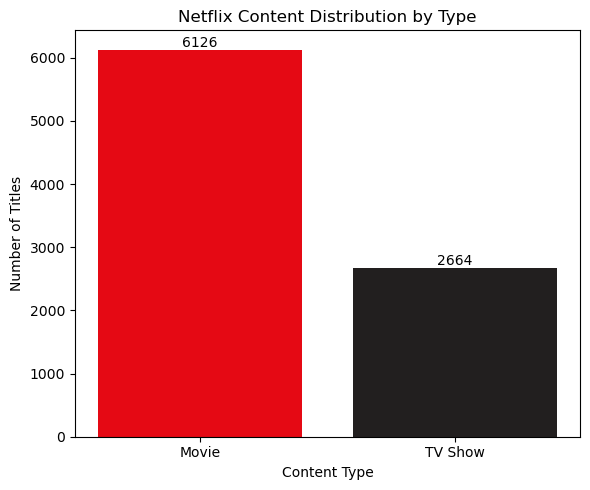

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))

bars =plt.bar(content_type.index,content_type.values,color=["#E50914", "#221F1F"])
plt.title("Netflix Content Distribution by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,value + 50,str(int(value)),
    ha="center")
plt.tight_layout()
plt.show()

### Visualization 1: Netflix Content Distribution by Type

This bar chart compares the number of Movies and TV Shows available in the Netflix dataset.

The visualization shows that Movies make up a significantly larger portion of the catalog than TV Shows, indicating a stronger representation of movie content in the dataset.

In [ ]:
#Step3.2-Netflix Content Trend by Release Year.

#Prepare yearly data
yearly_content = (df["release_year"].value_counts().sort_index())

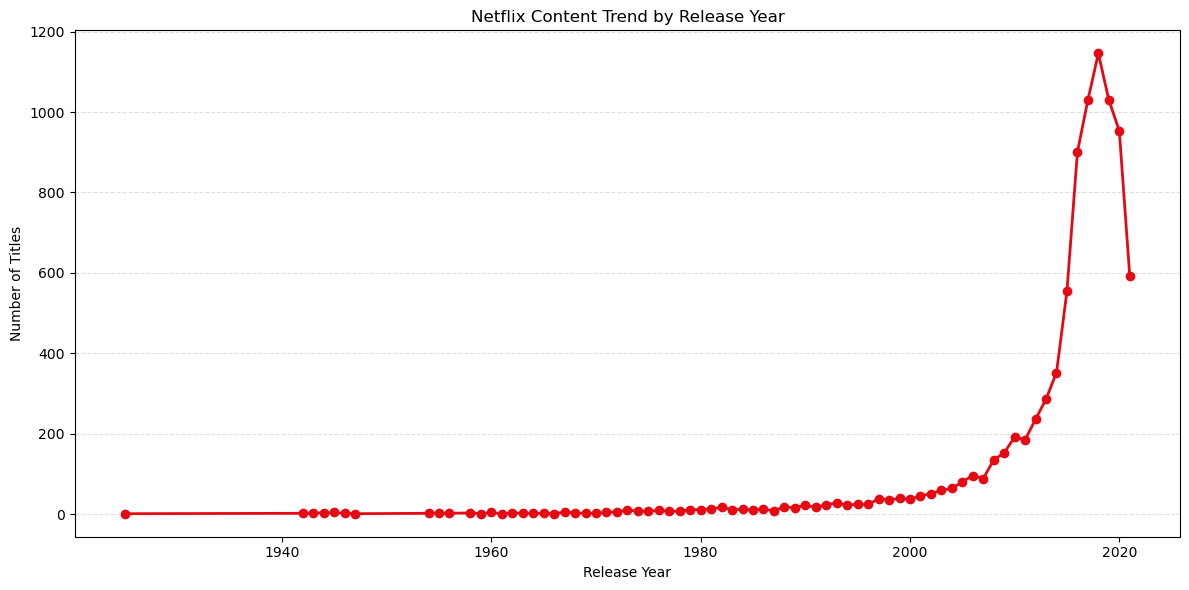

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(yearly_content.index,yearly_content.values,marker="o",linewidth=2,
    color="#E50914")
plt.title("Netflix Content Trend by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Visualization 2: Netflix Content Trend by Release Year

This line chart illustrates the number of Netflix titles across different release years.

The visualization helps identify changes in content production over time, including periods of growth, decline, and significant changes in the volume of available content.

This trend provides useful context for understanding how Netflix's content catalog has evolved over the years.

In [29]:
#Step 3.3 — Content Rating Distribution. 

rating_counts = df["rating"].value_counts()

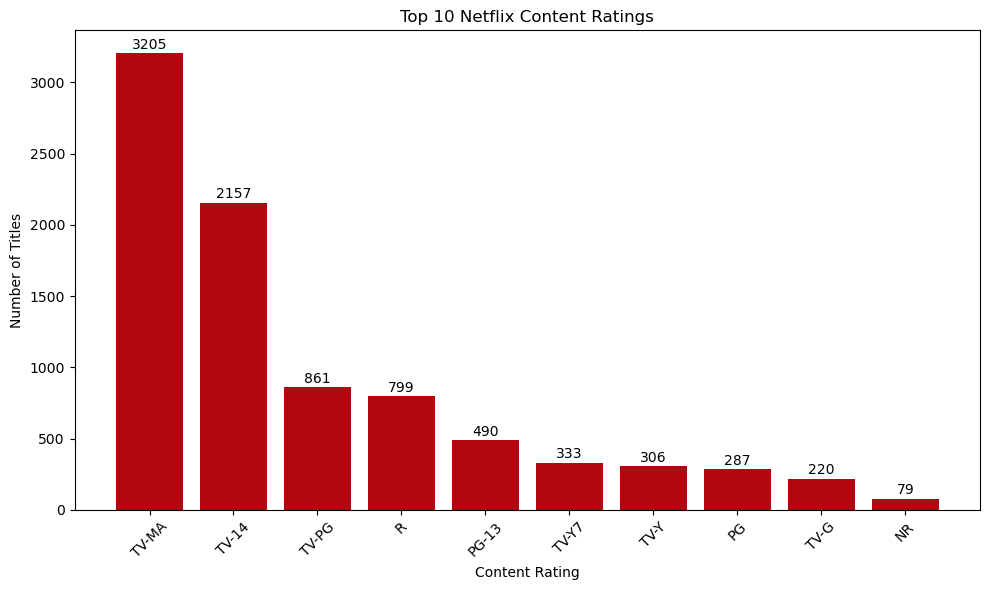

In [30]:
plt.figure(figsize=(10, 6))

bars = plt.bar(top_ratings.index,top_ratings.values,color="#B20710")
plt.title("Top 10 Netflix Content Ratings")
plt.xlabel("Content Rating")
plt.ylabel("Number of Titles")
for bar in bars:
    value = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,value + 30,str(int(value)),
    ha="center")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualization 3: Content Rating Distribution

This bar chart presents the top 10 content ratings in the Netflix dataset.

TV-MA is the most frequently occurring rating, followed by TV-14 and TV-PG. The distribution indicates a strong presence of content targeted toward mature and teenage audiences.

Analyzing content ratings provides useful insights into Netflix's audience focus and content strategy.

In [32]:
#Step 3.4 — Top 10 Genres
genre_data = (df["listed_in"].dropna().str.split(",").explode().str.strip())
genre_counts = genre_data.value_counts()

top_genres = genre_counts.head(10)

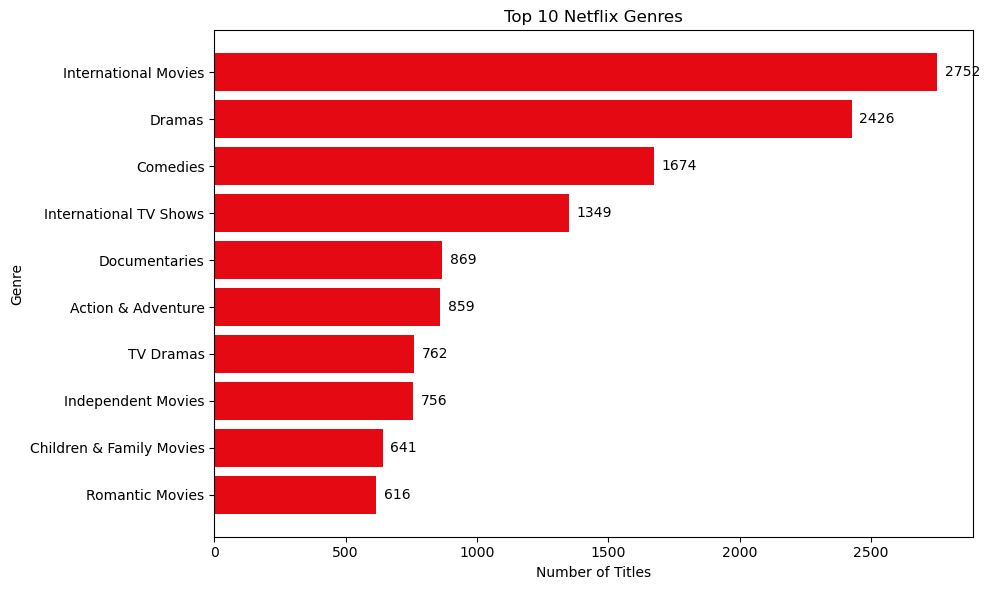

In [33]:
plt.figure(figsize=(10, 6))

bars = plt.barh(top_genres.index,top_genres.values,color="#E50914")
plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.gca().invert_yaxis()

for bar in bars:
    value = bar.get_width()
    plt.text(value + 30,bar.get_y() + bar.get_height() / 2,str(int(value)),
    va="center")
plt.tight_layout()
plt.show()

### Visualization 4: Top 10 Netflix Genres

This horizontal bar chart presents the 10 most frequently occurring genres and categories in the Netflix dataset.

International Movies have the highest number of content-genre associations, followed by Dramas and Comedies. The visualization highlights the diversity of Netflix's content catalog and the strong presence of international and drama-based content.

*Note: A single title can belong to multiple genres, so these values represent genre-content associations rather than unique titles.*

In [34]:
#Step 4 — Generate Actionable Business Insights

#Create a Business Insights Table
business_insights = pd.DataFrame({
    "Business Area": ["Content Strategy","Audience Targeting","Genre Strategy",
        "International Content","Content Production"],
  "Key Insight": [
    "Movies form a significantly larger portion of the catalog than TV Shows.",
    "TV-MA and TV-14 are the most common content ratings.",
    "International Movies, Dramas, and Comedies are among the leading categories.",
    "International content represents a major part of the Netflix catalog.",
    "Release-year trends show changes in content volume over time."],
   "Business Recommendation": [
      "Maintain a strong movie portfolio while selectively expanding TV content.",
      "Continue serving mature and teen audiences while maintaining family-friendly content.",
      "Continue investing in successful international, drama, and comedy categories.",
      "Expand regional and localized content based on market demand.",
      "Use historical trends to improve future content planning and investment."]
})
business_insights

,Business Area,Key Insight,Business Recommendation
0,Content Strategy,Movies form a significantly larger portion of ...,Maintain a strong movie portfolio while select...
1,Audience Targeting,TV-MA and TV-14 are the most common content ra...,Continue serving mature and teen audiences whi...
2,Genre Strategy,"International Movies, Dramas, and Comedies are...",Continue investing in successful international...
3,International Content,International content represents a major part ...,Expand regional and localized content based on...
4,Content Production,Release-year trends show changes in content vo...,Use historical trends to improve future conten...


## Step 4: Generate Actionable Business Insights

The findings from the exploratory analysis and visualizations were translated into actionable business insights.

### Key Business Areas Analyzed:
- Content strategy
- Audience targeting
- Genre performance
- International content
- Content production trends

The analysis indicates that Netflix has a strong movie-focused catalog, significant representation of mature and teen-oriented content, and a strong presence of international, drama, and comedy categories.

These insights can support content planning, audience targeting, regional expansion, and future content investment decisions.

In [35]:
#Step 5: Prepare the Final Analytical Report

# Netflix Business Insights Report

## Executive Summary

This report presents a comprehensive analysis of the Netflix dataset to identify important content trends, audience patterns, genre preferences, and potential business opportunities.

The analysis covered exploratory data analysis, content type distribution, release-year trends, content ratings, and genre analysis. The findings were visualized using charts and translated into actionable business insights.

Overall, the analysis shows that Netflix has a strong movie-focused catalog, significant representation of mature and teen-oriented content, and a diverse content portfolio with strong international, drama, and comedy categories.

## Dataset Overview

The cleaned Netflix dataset contains **8,790 records** and **10 columns**.

### Dataset Statistics

- Total Records: **8,790**
- Total Columns: **10**
- Unique Titles: **8,787**
- Unique Release Years: **74**
- Movies: **6,126**
- TV Shows: **2,664**

The dataset contains information about Netflix titles including content type, title, director, country, release year, rating, duration, and genre/category information.

## Key Findings

### Content Type
- Movies account for the majority of the Netflix catalog with **6,126 titles**.
- TV Shows account for **2,664 titles**.

### Content Ratings
- **TV-MA** is the most common rating with **3,205 titles**.
- **TV-14** is the second most common rating with **2,157 titles**.
- **TV-PG** follows with **861 titles**.

### Genre Distribution
- **International Movies** have the highest number of genre-content associations with **2,752**.
- **Dramas** follow with **2,426**.
- **Comedies** account for **1,674** associations.
- International TV Shows are also strongly represented with **1,349** associations.

### Release-Year Trends
- The release-year analysis highlights changes in the volume of Netflix content across different periods.
- These trends provide useful context for understanding the evolution of Netflix's content catalog.

## Business Insights

The analysis provides several important business insights:

1. **Strong Movie Presence:**  
   Movies represent a significantly larger portion of the catalog, indicating a strong emphasis on movie content.

2. **Mature and Teen Audience Focus:**  
   The high number of TV-MA and TV-14 titles suggests significant focus on mature and teenage audiences.

3. **Strong International Presence:**  
   International Movies and International TV Shows are among the most frequently occurring categories, highlighting the importance of global content.

4. **Genre Diversity:**  
   Drama, comedy, documentary, action, and family-oriented categories contribute to a diverse content portfolio.

5. **Changing Content Landscape:**  
   Release-year trends show how the volume of content has changed over time and can help inform future content planning.

## Business Recommendations

Based on the analysis, the following recommendations can be considered:

- Continue maintaining a strong movie portfolio while selectively expanding TV Show content.
- Maintain a balanced content strategy for mature, teenage, and family audiences.
- Continue investing in international and localized content to strengthen global reach.
- Identify high-performing genres and explore opportunities in emerging categories.
- Use historical content trends to support future content acquisition and production planning.
- Combine content performance data with regional audience preferences to improve personalization and content investment decisions.

## Conclusion

The Netflix dataset provides valuable insights into the platform's content strategy and catalog composition.

The analysis demonstrates the importance of combining data cleaning, exploratory analysis, visualization, and business interpretation to transform raw data into meaningful insights.

This project strengthened my practical skills in **Python, Pandas, Matplotlib, exploratory data analysis, data visualization, and business-oriented insight generation**.

The findings can serve as a foundation for further analysis, such as regional content performance, audience segmentation, recommendation systems, and predictive content analytics.